# 09. E-Ammonia & E-Methanol Production

This model introduces the first **chemical reaction links**: hydrogen combined with a second
feedstock (nitrogen or captured CO2) to synthesize a higher-value product (ammonia or methanol).
Where every link so far has had one input and one output, `Haber_Bosch` and `Methanol_Synthesis`
each have **two inputs and one output**, all tied together at fixed stoichiometric ratios.

The objective is to extend the Model 08 system (full electricity + heat + hydrogen stack) with a
**Haber-Bosch reactor** producing ammonia and a **methanol synthesis reactor**, each drawing hydrogen
from the same `hydrogen_bus` as the existing industrial offtake — competing for the same pool of H2 —
plus a secondary feedstock (nitrogen or CO2) purchased from a simplified external source. Both
products can then be sold to an export market.

## 🛠️ System Topology
1. **Buses:** `electricity_bus`, `heat_bus`, `hydrogen_bus` (all unchanged from Model 08), plus four
   new buses: `nitrogen_bus`, `co2_bus`, `ammonia_bus`, `methanol_bus`. Unlike the energy buses so
   far, these four carry mass flow (**tonnes/h**), not power (MW) — a reminder that not every bus in
   a PyPSA network has to represent energy.
2. **Generators (Feedstock Source):** `N2_Source` and `CO2_Source` — simplified external suppliers
   of nitrogen (from air, cheap) and captured CO2 (from a point-source capture facility, more
   expensive), each priced per tonne.
3. **Generators (Product Sink):** `Ammonia_Market` and `Methanol_Market` — the same negative-generator
   market-sink pattern used for `Grid_Export` since Model 01, now selling tonnes of product instead
   of MWh of electricity.
4. **Links (chemical reactions):** `Haber_Bosch` (H2 + N2 → NH3) and `Methanol_Synthesis`
   (H2 + CO2 → CH3OH), each a `Link` with `bus0` as the primary hydrogen input, `bus1` as the product
   output, and `bus2` as the secondary feedstock — given a **negative** efficiency, since it's
   consumed rather than produced.

### A note on the numbers
The conversion ratios below come from simple mass-balance stoichiometry (N₂ + 3H₂ → 2NH₃, and
CO₂ + 3H₂ → CH₃OH + H₂O) applied to hydrogen's LHV energy content — they capture the chemistry, but
skip the extra process electricity real plants need for compression and separation. Feedstock and
product prices are broad, illustrative figures, not sourced quotes. Treat this model as a lesson in
*how to wire up a multi-input chemical link in PyPSA*, not as a bankable techno-economic study.

<img src="../assets/model_9.jpg" alt="Model 09 System Topology" width="800">


In [1]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

# Import custom publication-quality plotting style
sys.path.append('../')
from utils.viz_utils import set_nature_style

# Activate global styling
set_nature_style()

# Load processed data
df_pv = pd.read_csv('../data/processed/pv_2025_hourly.csv', index_col='time', parse_dates=True)
df_wind = pd.read_csv('../data/processed/wind_2025_hourly.csv', index_col='time', parse_dates=True)
df_price = pd.read_csv('../data/processed/electricity_price_2025_hourly.csv', index_col='time', parse_dates=True)

# This completely eliminates any duplicate timestamps caused by Daylight Saving Time.
perfect_index = pd.date_range(start='2025-01-01 00:00', end='2025-12-31 23:00', freq='1h')

# Force all three dataframes to use this clean index
df_pv.index = perfect_index
df_wind.index = perfect_index
df_price.index = perfect_index

df_pv['capacity_factor'] = df_pv['pv_generation_kw'].clip(upper=1.0)
df_wind['capacity_factor'] = df_wind['wind_generation_kw'].clip(upper=1.0)


## ⚙️ Technical Parameters

All electricity, heat, and hydrogen-side parameters are carried over from Model 08, with the
electrolyzer's capacity increased slightly (4 MW → 6 MW) to give it enough headroom to feed both the
existing industrial H2 offtake and the two new synthesis reactors. New entries define the reaction
stoichiometry, feedstock costs, and product prices.


In [2]:
H2_LHV_MWH_PER_TONNE = 33.33  # MWh per tonne of hydrogen (LHV basis)

# Haber-Bosch stoichiometry: N2 + 3H2 -> 2NH3 (molar masses: N2=28, H2=2, NH3=17)
h2_per_tonne_nh3 = (3 * 2) / (2 * 17)          # tonne H2 per tonne NH3 = 0.1765
n2_per_tonne_nh3 = 28 / (2 * 17)               # tonne N2 per tonne NH3 = 0.8235
h2_mwh_per_tonne_nh3 = h2_per_tonne_nh3 * H2_LHV_MWH_PER_TONNE

# Methanol synthesis stoichiometry: CO2 + 3H2 -> CH3OH + H2O (molar masses: CO2=44, H2=6, CH3OH=32)
h2_per_tonne_meoh = 6 / 32                     # tonne H2 per tonne MeOH = 0.1875
co2_per_tonne_meoh = 44 / 32                   # tonne CO2 per tonne MeOH = 1.375
h2_mwh_per_tonne_meoh = h2_per_tonne_meoh * H2_LHV_MWH_PER_TONNE

# Centralized dictionary for technical and economic parameters
tech_param = {
    'solar_pv': {
        'p_nom': 10.0,
        'marginal_cost': 0.0
    },
    'wind': {
        'p_nom': 15.0,
        'marginal_cost': 0.0
    },
    'market_grid': {
        'import_p_nom': 20.0,
        'export_p_nom': 18.0
    },
    'demand': {
        'day_load_mw': 8.0,
        'night_load_mw': 4.0
    },
    'battery': {
        'p_nom': 4.0,
        'max_hours': 2.0,
        'efficiency_store': 0.95,
        'efficiency_dispatch': 0.95
    },
    'heat_pump': {
        'p_nom': 1.0,
        'cop': 3.5,
        'marginal_cost': 0.5
    },
    'electric_boiler': {
        'p_nom': 5.0,
        'efficiency': 0.99,
        'marginal_cost': 1.0
    },
    'heat_demand': {
        'avg_mw': 3.0,
        'amplitude_mw': 2.0
    },
    'thermal_storage': {
        'e_nom': 40.0,
        'standing_loss': 0.01
    },
    'electrolyzer': {
        'p_nom': 6.0,            # Increased from Model 08's 4 MW to feed two new offtakes
        'efficiency': 0.65,
        'marginal_cost': 0.0
    },
    'hydrogen_storage': {
        'e_nom': 20.0,
        'standing_loss': 0.0
    },
    'h2_demand': {
        'avg_mw': 1.5
    },
    'haber_bosch': {
        'p_nom': 2.0,                              # Max hydrogen input rating, MW (LHV)
        'efficiency': 1 / h2_mwh_per_tonne_nh3,     # tonne NH3 produced per MWh H2 in
        'efficiency2': -n2_per_tonne_nh3 / h2_mwh_per_tonne_nh3  # tonne N2 consumed per MWh H2 in (negative = input)
    },
    'methanol_synthesis': {
        'p_nom': 2.0,                                # Max hydrogen input rating, MW (LHV)
        'efficiency': 1 / h2_mwh_per_tonne_meoh,      # tonne MeOH produced per MWh H2 in
        'efficiency2': -co2_per_tonne_meoh / h2_mwh_per_tonne_meoh  # tonne CO2 consumed per MWh H2 in
    },
    'feedstock_price': {
        'n2_eur_per_tonne': 20.0,    # Air separation - cheap
        'co2_eur_per_tonne': 60.0    # Captured CO2 (point-source, not DAC) - more expensive
    },
    'product_price': {
        'nh3_eur_per_tonne': 500.0,
        'meoh_eur_per_tonne': 550.0
    }
}

print(f"Haber-Bosch:  {tech_param['haber_bosch']['efficiency']:.3f} t NH3/MWh H2,  "
      f"{-tech_param['haber_bosch']['efficiency2']:.3f} t N2/MWh H2")
print(f"Methanol:     {tech_param['methanol_synthesis']['efficiency']:.3f} t MeOH/MWh H2,  "
      f"{-tech_param['methanol_synthesis']['efficiency2']:.3f} t CO2/MWh H2")


Haber-Bosch:  0.170 t NH3/MWh H2,  0.140 t N2/MWh H2
Methanol:     0.160 t MeOH/MWh H2,  0.220 t CO2/MWh H2


## 🏗️ Initializing the Network

Four new buses join the three carried over from Model 08. `nitrogen_bus` and `co2_bus` carry the raw
feedstocks; `ammonia_bus` and `methanol_bus` carry the finished products.


In [3]:
# Initialize a new PyPSA network
n = pypsa.Network()
n.set_snapshots(df_pv.index)

# Energy buses (carried over from Model 08)
n.add("Bus", "electricity_bus")
n.add("Bus", "heat_bus")
n.add("Bus", "hydrogen_bus")

# New mass-flow buses (tonnes/h, not MW)
n.add("Bus", "nitrogen_bus")
n.add("Bus", "co2_bus")
n.add("Bus", "ammonia_bus")
n.add("Bus", "methanol_bus")


Index(['methanol_bus'], dtype='object')

## ⚡ Adding Generators and the Grid Connection

Solar, Wind, `Grid_Import`, and `Grid_Export` are added exactly as in Model 08.


In [4]:
n.add("Generator", "Solar_PV", bus="electricity_bus",
      p_nom=tech_param['solar_pv']['p_nom'],
      p_max_pu=df_pv['capacity_factor'],
      marginal_cost=tech_param['solar_pv']['marginal_cost'])

n.add("Generator", "Wind", bus="electricity_bus",
      p_nom=tech_param['wind']['p_nom'],
      p_max_pu=df_wind['capacity_factor'],
      marginal_cost=tech_param['wind']['marginal_cost'])

n.add("Generator", "Grid_Import", bus="electricity_bus",
      p_nom=tech_param['market_grid']['import_p_nom'],
      marginal_cost=df_price['price'])

n.add("Generator", "Grid_Export", bus="electricity_bus",
      p_nom=tech_param['market_grid']['export_p_nom'],
      p_min_pu=-1.0, p_max_pu=0.0,
      marginal_cost=df_price['price'])


Index(['Grid_Export'], dtype='object')

## 🎯 Adding the Electrical, Heat, and Hydrogen Demands

The industrial, heat, and hydrogen demands are unchanged from Model 08. The hydrogen offtake still
sits directly on `hydrogen_bus`, so it now competes with the two new synthesis reactors for the same
pool of hydrogen.


In [5]:
is_daytime = (n.snapshots.hour >= 8) & (n.snapshots.hour < 18)
electrical_load = np.where(is_daytime, tech_param['demand']['day_load_mw'], tech_param['demand']['night_load_mw'])
electrical_load = pd.Series(electrical_load, index=n.snapshots)
n.add("Load", "Industrial_Load", bus="electricity_bus", p_set=electrical_load)

day_of_year = n.snapshots.dayofyear
heat_load = tech_param['heat_demand']['avg_mw'] - tech_param['heat_demand']['amplitude_mw'] * np.sin(
    (day_of_year - 80) * 2 * np.pi / 365
)
heat_load = pd.Series(np.clip(heat_load, 0.2, None), index=n.snapshots)
n.add("Load", "Heat_Demand", bus="heat_bus", p_set=heat_load)

h2_load = pd.Series(tech_param['h2_demand']['avg_mw'], index=n.snapshots)
n.add("Load", "H2_Demand", bus="hydrogen_bus", p_set=h2_load)


Index(['H2_Demand'], dtype='object')

## 🔋 Adding Storage, Heat Pump, Boiler, Electrolyzer, and H2 Storage

All added exactly as in Model 08, other than the electrolyzer's larger `p_nom` already reflected in
`tech_param`.


In [6]:
n.add("StorageUnit", "Battery", bus="electricity_bus",
      p_nom=tech_param['battery']['p_nom'],
      max_hours=tech_param['battery']['max_hours'],
      efficiency_store=tech_param['battery']['efficiency_store'],
      efficiency_dispatch=tech_param['battery']['efficiency_dispatch'],
      cyclic_state_of_charge=True)

n.add("Store", "Thermal_Storage", bus="heat_bus",
      e_nom=tech_param['thermal_storage']['e_nom'],
      e_cyclic=True,
      standing_loss=tech_param['thermal_storage']['standing_loss'])

n.add("Link", "Heat_Pump", bus0="electricity_bus", bus1="heat_bus",
      p_nom=tech_param['heat_pump']['p_nom'],
      efficiency=tech_param['heat_pump']['cop'],
      marginal_cost=tech_param['heat_pump']['marginal_cost'])

n.add("Link", "Electric_Boiler", bus0="electricity_bus", bus1="heat_bus",
      p_nom=tech_param['electric_boiler']['p_nom'],
      efficiency=tech_param['electric_boiler']['efficiency'],
      marginal_cost=tech_param['electric_boiler']['marginal_cost'])

n.add("Link", "Electrolyzer", bus0="electricity_bus", bus1="hydrogen_bus",
      p_nom=tech_param['electrolyzer']['p_nom'],
      efficiency=tech_param['electrolyzer']['efficiency'],
      marginal_cost=tech_param['electrolyzer']['marginal_cost'])

n.add("Store", "Hydrogen_Storage", bus="hydrogen_bus",
      e_nom=tech_param['hydrogen_storage']['e_nom'],
      e_cyclic=True,
      standing_loss=tech_param['hydrogen_storage']['standing_loss'])


Index(['Hydrogen_Storage'], dtype='object')

## 🧪 Adding Feedstock Sources and Chemical Reaction Links

`N2_Source` and `CO2_Source` are ordinary generators — unlimited supply, priced per tonne, exactly
like any other source in this series, just on a mass-flow bus instead of an energy bus.

`Haber_Bosch` and `Methanol_Synthesis` are where the new mechanic lives: `bus2` carries a **negative**
efficiency, meaning that bus is drawn *down* rather than up whenever the link is active — the reactor
consumes N2 (or CO2) in fixed proportion to the hydrogen it consumes, exactly matching the
stoichiometry calculated in the parameters cell above.


In [7]:
# Feedstock sources
n.add("Generator", "N2_Source", bus="nitrogen_bus",
      p_nom=100.0, marginal_cost=tech_param['feedstock_price']['n2_eur_per_tonne'])

n.add("Generator", "CO2_Source", bus="co2_bus",
      p_nom=100.0, marginal_cost=tech_param['feedstock_price']['co2_eur_per_tonne'])

# Haber-Bosch: H2 (bus0, consumed) + N2 (bus2, consumed) -> NH3 (bus1, produced)
n.add("Link", "Haber_Bosch",
      bus0="hydrogen_bus", bus1="ammonia_bus", bus2="nitrogen_bus",
      p_nom=tech_param['haber_bosch']['p_nom'],
      efficiency=tech_param['haber_bosch']['efficiency'],
      efficiency2=tech_param['haber_bosch']['efficiency2'])

# Methanol Synthesis: H2 (bus0, consumed) + CO2 (bus2, consumed) -> CH3OH (bus1, produced)
n.add("Link", "Methanol_Synthesis",
      bus0="hydrogen_bus", bus1="methanol_bus", bus2="co2_bus",
      p_nom=tech_param['methanol_synthesis']['p_nom'],
      efficiency=tech_param['methanol_synthesis']['efficiency'],
      efficiency2=tech_param['methanol_synthesis']['efficiency2'])

# Product markets - same negative-generator sink pattern as Grid_Export since Model 01
n.add("Generator", "Ammonia_Market", bus="ammonia_bus",
      p_nom=10.0, p_min_pu=-1.0, p_max_pu=0.0,
      marginal_cost=tech_param['product_price']['nh3_eur_per_tonne'])

n.add("Generator", "Methanol_Market", bus="methanol_bus",
      p_nom=10.0, p_min_pu=-1.0, p_max_pu=0.0,
      marginal_cost=tech_param['product_price']['meoh_eur_per_tonne'])


Index(['Methanol_Market'], dtype='object')

## 🧠 Running the Optimization

The solver now has to allocate a single, limited hydrogen supply across three competing uses (fixed
industrial H2 demand, ammonia synthesis, methanol synthesis), fund it from electricity generation and
grid import, and weigh feedstock costs against product revenue for both reactors — all at once, across
the full year.


In [8]:
status, condition = n.optimize(solver_name='highs')

print(f"Solver Status: {status}")
print(f"Total Objective Value (Net Cost): €{n.objective:,.2f}")


Index(['Thermal_Storage', 'Hydrogen_Storage'], dtype='object', name='Store')
Index(['electricity_bus', 'heat_bus', 'hydrogen_bus', 'nitrogen_bus',
       'co2_bus', 'ammonia_bus', 'methanol_bus'],
      dtype='object', name='Bus')
Index(['Heat_Pump', 'Electric_Boiler', 'Electrolyzer', 'Haber_Bosch',
       'Methanol_Synthesis'],
      dtype='object', name='Link')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 12.26it/s]
INFO:linopy.io: Writing time: 3.05s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 175200 primals, 402960 duals
Objective: 1.15e+04
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper, Store-fix-e-lower, Store-fix-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-

Solver Status: ok
Total Objective Value (Net Cost): €11,517.59


## 📊 Analyzing the Results

We split total hydrogen production across its three destinations, then look at how much ammonia and
methanol were actually produced and sold, and what revenue each reactor generated net of its
feedstock cost.


Total Hydrogen Produced:        15,218.60 MWh
  - to Industrial H2 Demand:    13,140.00 MWh (86.3%)
  - to Haber-Bosch (NH3):       2,065.00 MWh (13.6%)
  - to Methanol Synthesis:      13.60 MWh (0.1%)
--------------------------------------------------
Ammonia Produced:               351.09 t   |  Revenue: €175,542.55  |  N2 Cost: €5,782.58
Methanol Produced:              2.18 t   |  Revenue: €1,196.92  |  CO2 Cost: €179.54
--------------------------------------------------
Net Margin, Ammonia:            €169,759.98
Net Margin, Methanol:           €1,017.38


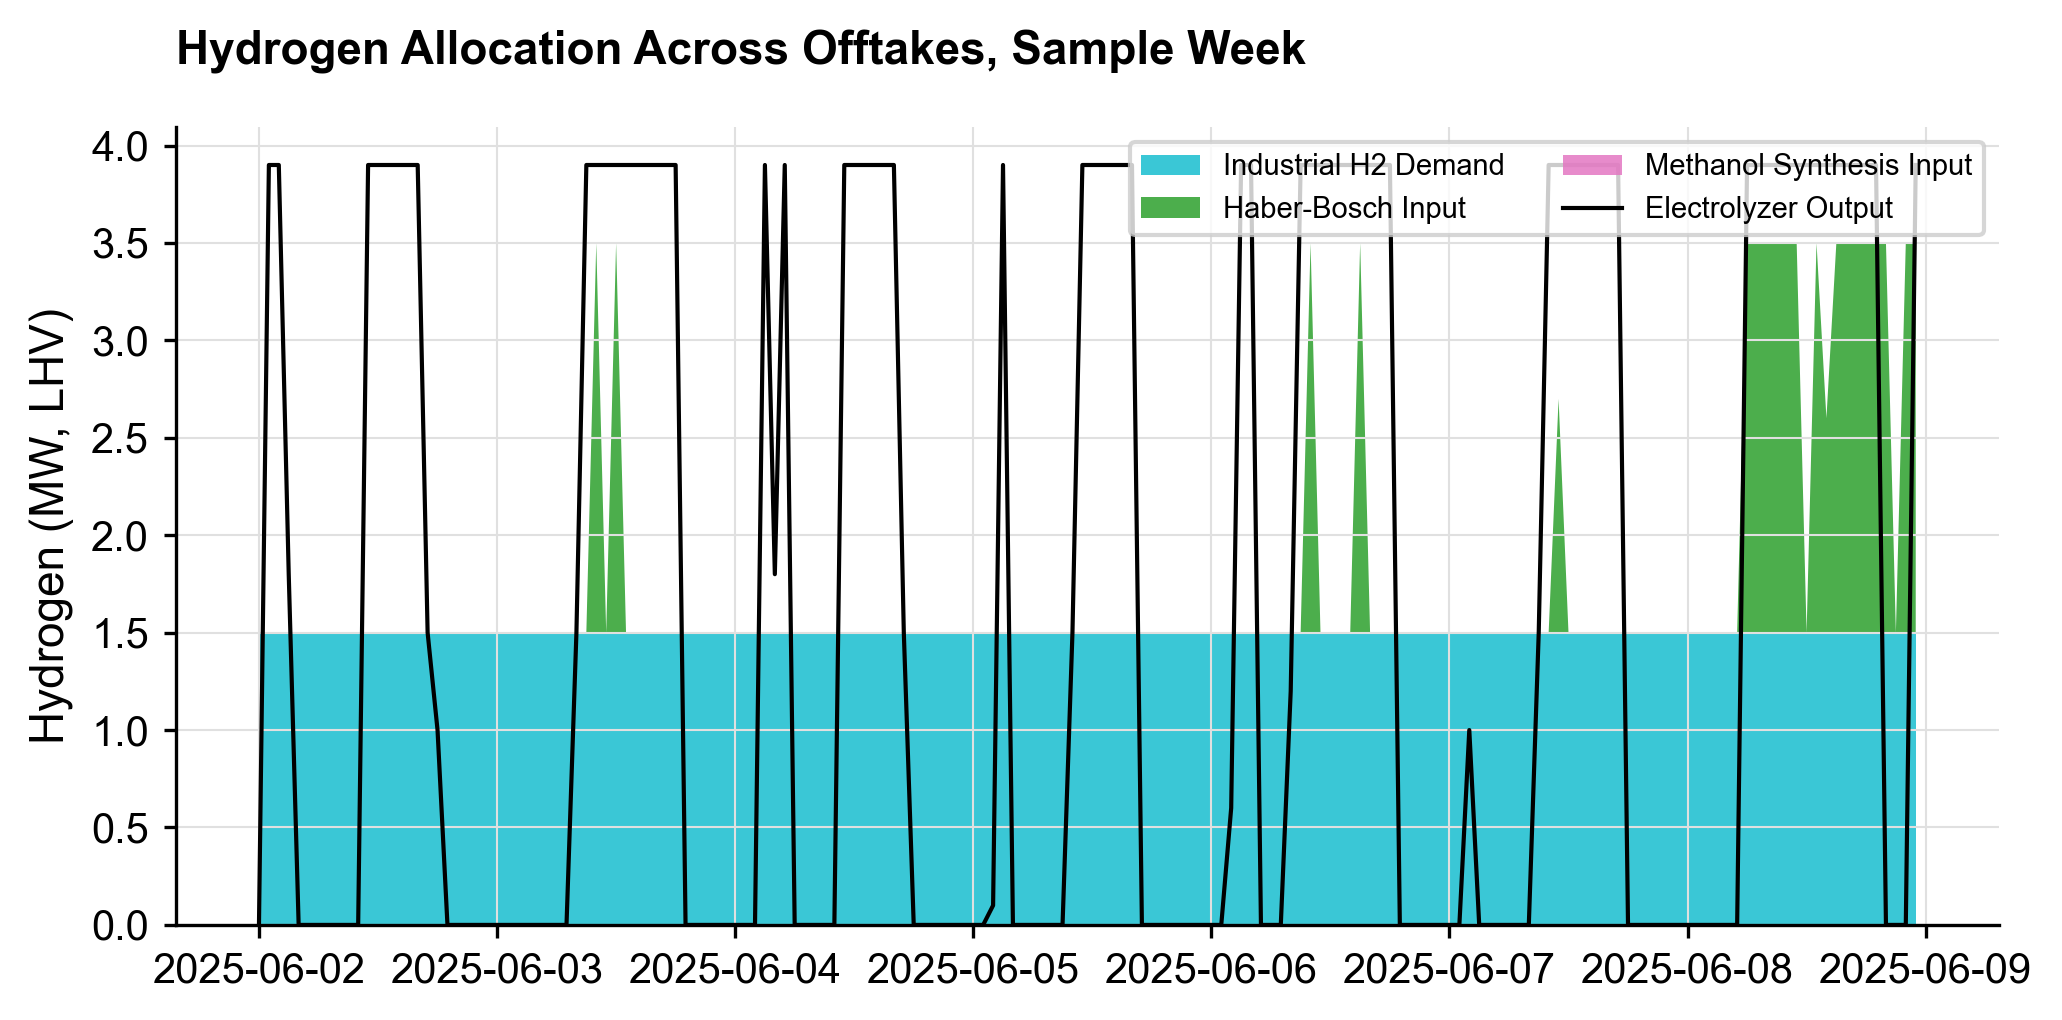

In [9]:
h2_produced_mwh = -n.links_t.p1['Electrolyzer'].sum()
h2_to_demand_mwh = h2_load.sum()
h2_to_ammonia_mwh = n.links_t.p0['Haber_Bosch'].sum()
h2_to_methanol_mwh = n.links_t.p0['Methanol_Synthesis'].sum()

nh3_produced_t = -n.links_t.p1['Haber_Bosch'].sum()
meoh_produced_t = -n.links_t.p1['Methanol_Synthesis'].sum()
n2_consumed_t = n.generators_t.p['N2_Source'].sum()
co2_consumed_t = n.generators_t.p['CO2_Source'].sum()

nh3_revenue_eur = (-n.generators_t.p['Ammonia_Market'] * tech_param['product_price']['nh3_eur_per_tonne']).sum()
meoh_revenue_eur = (-n.generators_t.p['Methanol_Market'] * tech_param['product_price']['meoh_eur_per_tonne']).sum()
n2_cost_eur = n2_consumed_t * tech_param['feedstock_price']['n2_eur_per_tonne']
co2_cost_eur = co2_consumed_t * tech_param['feedstock_price']['co2_eur_per_tonne']

print(f"Total Hydrogen Produced:        {h2_produced_mwh:,.2f} MWh")
print(f"  - to Industrial H2 Demand:    {h2_to_demand_mwh:,.2f} MWh ({100*h2_to_demand_mwh/h2_produced_mwh:.1f}%)")
print(f"  - to Haber-Bosch (NH3):       {h2_to_ammonia_mwh:,.2f} MWh ({100*h2_to_ammonia_mwh/h2_produced_mwh:.1f}%)")
print(f"  - to Methanol Synthesis:      {h2_to_methanol_mwh:,.2f} MWh ({100*h2_to_methanol_mwh/h2_produced_mwh:.1f}%)")
print("-" * 50)
print(f"Ammonia Produced:               {nh3_produced_t:,.2f} t   |  Revenue: €{nh3_revenue_eur:,.2f}  |  N2 Cost: €{n2_cost_eur:,.2f}")
print(f"Methanol Produced:              {meoh_produced_t:,.2f} t   |  Revenue: €{meoh_revenue_eur:,.2f}  |  CO2 Cost: €{co2_cost_eur:,.2f}")
print("-" * 50)
print(f"Net Margin, Ammonia:            €{nh3_revenue_eur - n2_cost_eur:,.2f}")
print(f"Net Margin, Methanol:           €{meoh_revenue_eur - co2_cost_eur:,.2f}")

# Plot hydrogen allocation across its three destinations, sample week
week = (n.snapshots >= '2025-06-02') & (n.snapshots < '2025-06-09')

fig, ax = plt.subplots()
ax.stackplot(n.snapshots[week],
             h2_load[week],
             n.links_t.p0['Haber_Bosch'][week],
             n.links_t.p0['Methanol_Synthesis'][week],
             labels=['Industrial H2 Demand', 'Haber-Bosch Input', 'Methanol Synthesis Input'],
             colors=['#17becf', '#2ca02c', '#e377c2'], alpha=0.85)
ax.plot(n.snapshots[week], -n.links_t.p1['Electrolyzer'][week], color='black', linewidth=1.0, label='Electrolyzer Output')
ax.set_ylabel('Hydrogen (MW, LHV)')
ax.set_title('Hydrogen Allocation Across Offtakes, Sample Week', pad=15, loc='left', fontweight='bold')
ax.legend(loc='upper right', ncol=2, fontsize=7)
plt.tight_layout()
plt.show()


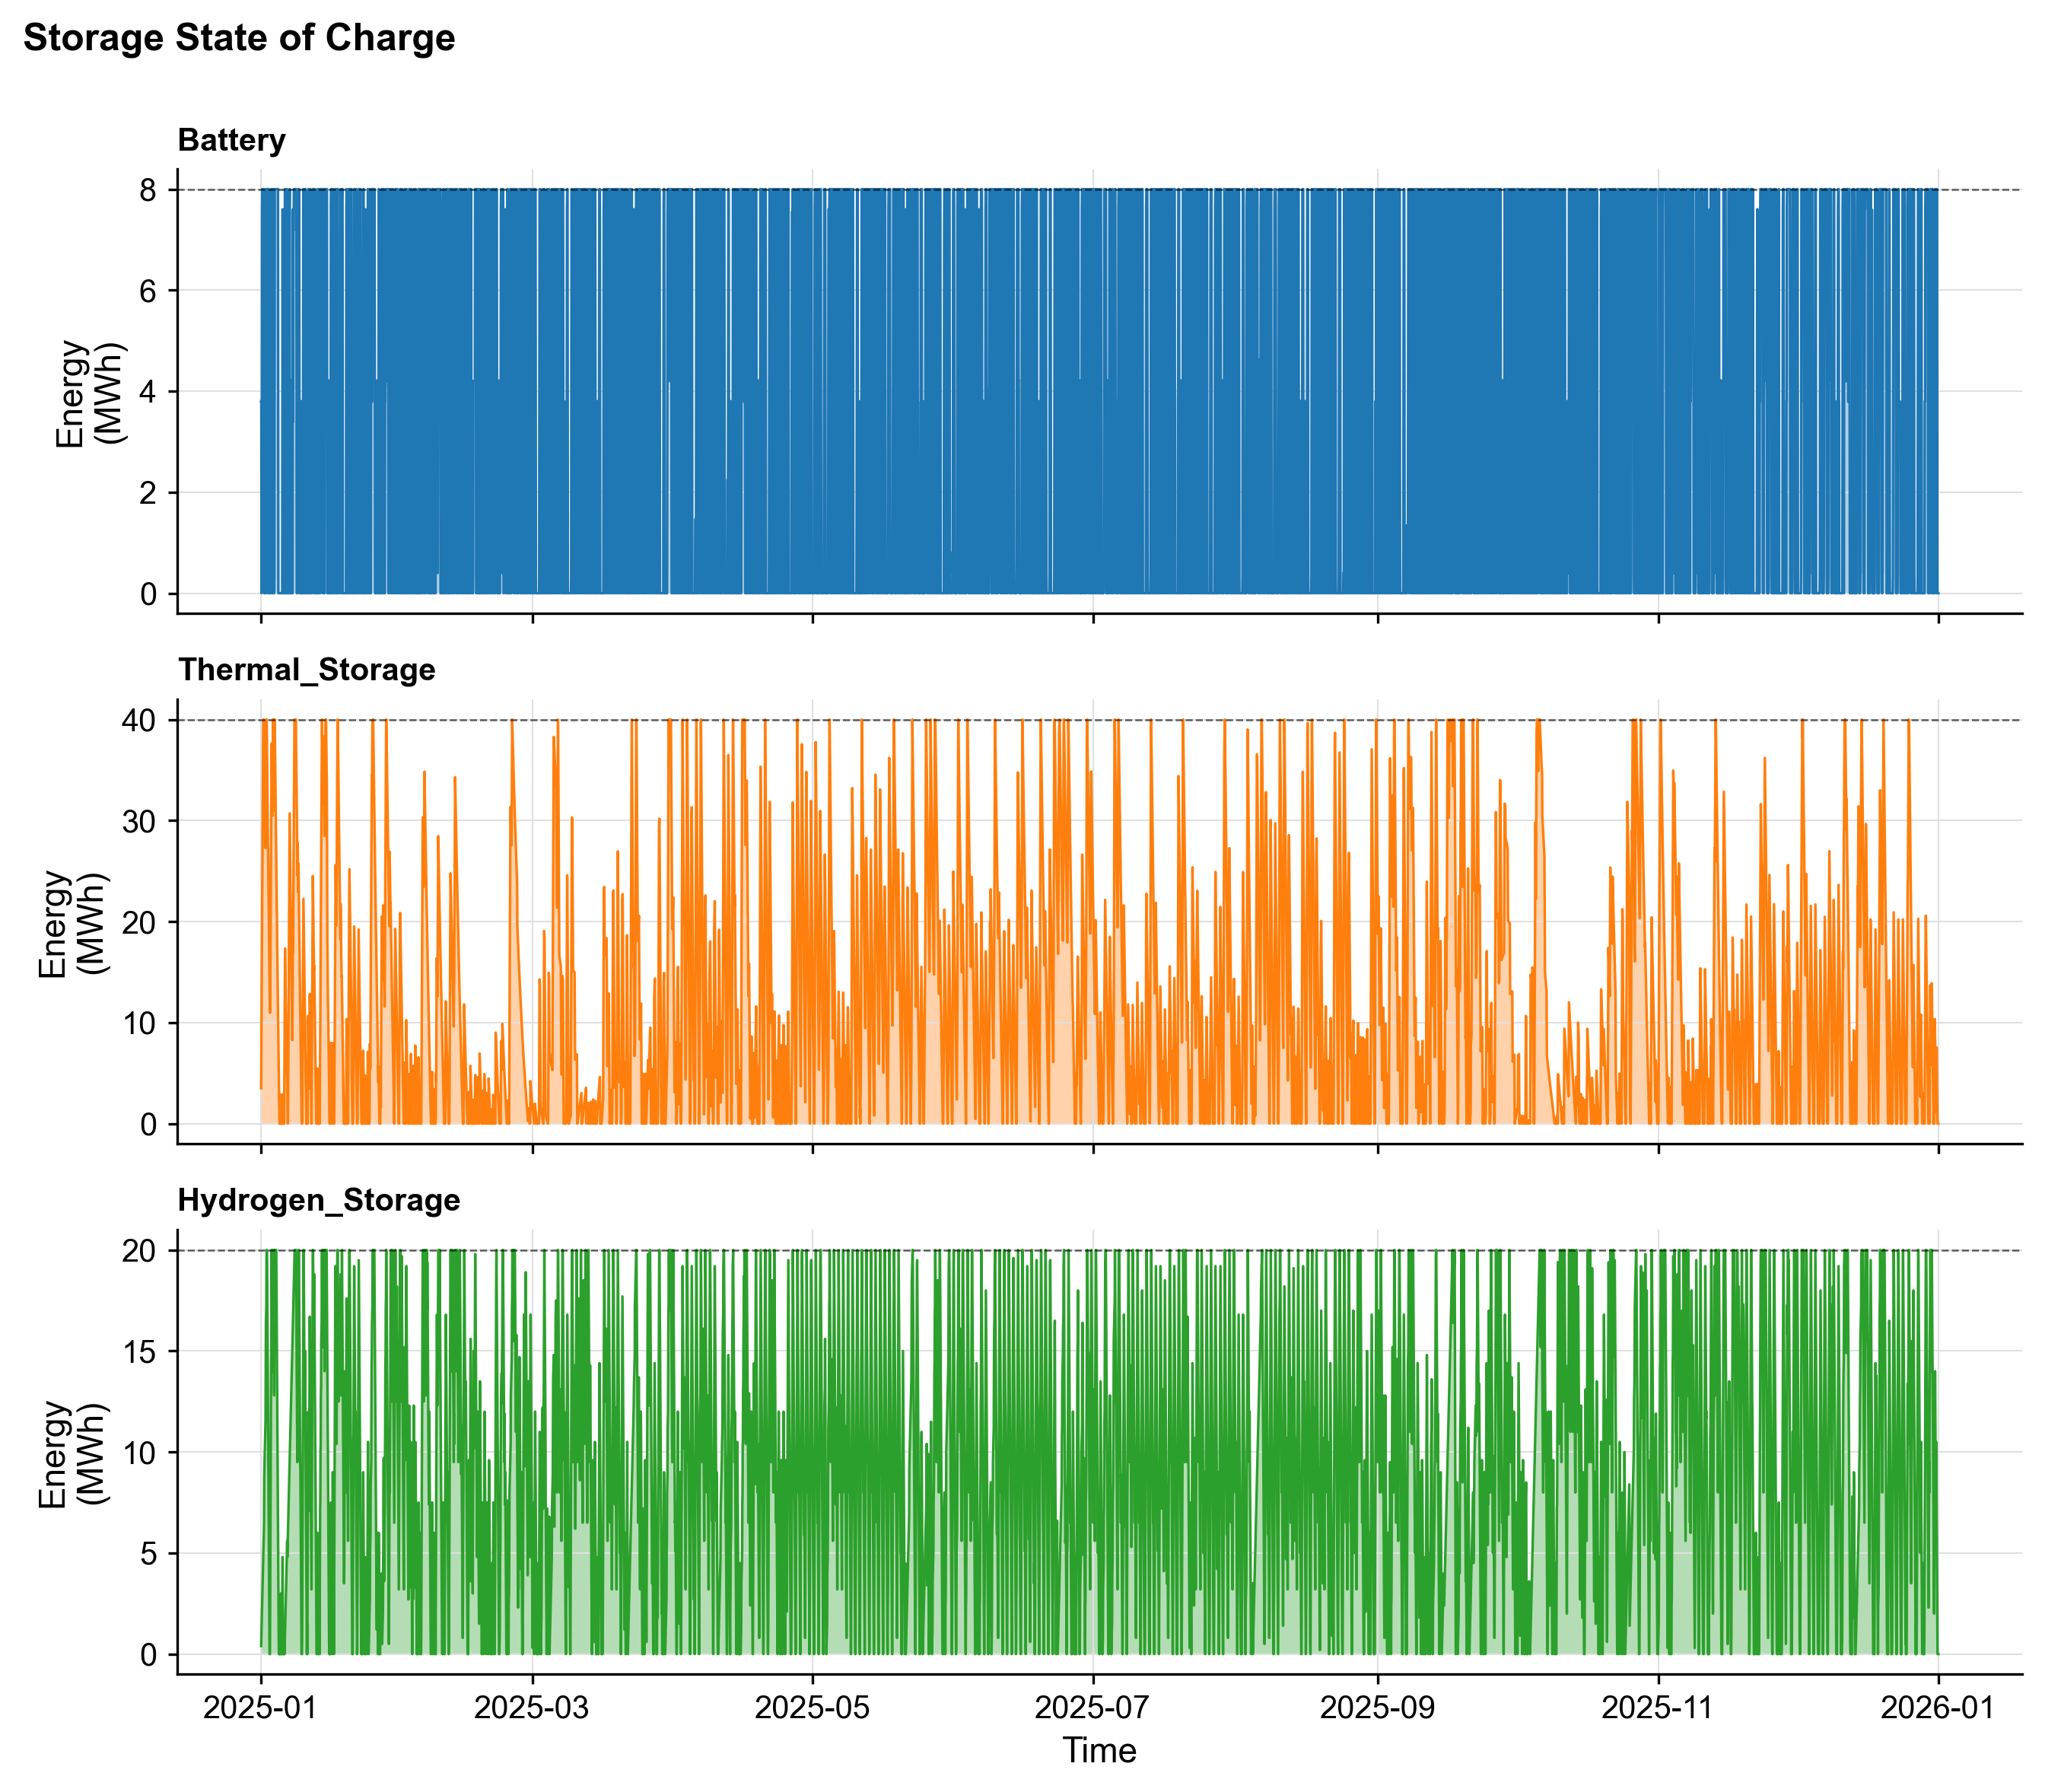

In [10]:
# ============================================================
# Plot State of Charge for every StorageUnit and Store
# ============================================================
soc_data = {}

for su in n.storage_units.index:
    capacity = n.storage_units.at[su, 'p_nom'] * n.storage_units.at[su, 'max_hours']
    soc_data[su] = (n.storage_units_t.state_of_charge[su], capacity)

for store in n.stores.index:
    capacity = n.stores.at[store, 'e_nom']
    soc_data[store] = (n.stores_t.e[store], capacity)

n_storage = len(soc_data)
fig, axes = plt.subplots(n_storage, 1, figsize=(9, 2.6 * n_storage), sharex=True)
if n_storage == 1:
    axes = [axes]

colors = plt.cm.tab10.colors

for ax, (name, (series, capacity)), color in zip(axes, soc_data.items(), colors):
    ax.fill_between(series.index, series, color=color, alpha=0.35, linewidth=0)
    ax.plot(series.index, series, color=color, linewidth=0.8)
    if capacity and capacity > 0:
        ax.axhline(capacity, color='black', linestyle='--', linewidth=0.6, alpha=0.6)
    ax.set_ylabel('Energy\n(MWh)')
    ax.set_title(name, pad=6, loc='left', fontsize=10, fontweight='bold')

axes[-1].set_xlabel('Time')
fig.suptitle('Storage State of Charge', x=0.01, ha='left', fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()